In [ ]:
!pip install tensorflow matplotlib numpy


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import time

from tensorflow.keras import layers, models, regularizers, callbacks
from tensorflow.keras.datasets import mnist, fashion_mnist, cifar10
from tensorflow.keras.utils import to_categorical

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Inline plots
%matplotlib inline

print("TensorFlow:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow: 2.20.0
GPU available: True


In [ ]:
def load_data(dataset_name):
    """Load and preprocess MNIST / Fashion-MNIST / CIFAR-10."""
    if dataset_name == 'mnist':
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
        x_test  = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

    elif dataset_name == 'fashion_mnist':
        (x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
        x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
        x_test  = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

    elif dataset_name == 'cifar10':
        (x_train, y_train), (x_test, y_test) = cifar10.load_data()
        x_train = x_train.astype('float32') / 255.0
        x_test  = x_test.astype('float32') / 255.0

    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    num_classes = 10
    y_train = to_categorical(y_train, num_classes)
    y_test  = to_categorical(y_test,  num_classes)

    # 10% validation split
    val_size = int(len(x_train) * 0.1)
    x_val, y_val       = x_train[:val_size], y_train[:val_size]
    x_train, y_train   = x_train[val_size:], y_train[val_size:]

    return (x_train, y_train), (x_val, y_val), (x_test, y_test)

print("Data loader ready.")

Data loader ready.


In [ ]:
def create_model(input_shape, num_classes=10,
                 l1=0.0, l2=0.0, dropout=0.0, use_bn=False):
    """CNN with optional L1/L2 regularization, Dropout and Batch Normalization."""
    reg = None
    if l1 > 0 or l2 > 0:
        reg = regularizers.l1_l2(l1=l1, l2=l2)

    inputs = layers.Input(shape=input_shape)

    # ---- Block 1 ----
    x = layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=reg)(inputs)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)

    # ---- Block 2 ----
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=reg)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)

    # ---- Classifier ----
    x = layers.Flatten()(x)
    x = layers.Dense(128, kernel_regularizer=reg)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Model builder ready.")

Model builder ready.


In [ ]:
def train_and_evaluate(dataset_name, model_config,
                       epochs=30, batch_size=128, verbose=0):
    (x_train, y_train), (x_val, y_val), (x_test, y_test) = load_data(dataset_name)

    model = create_model(
        input_shape=x_train.shape[1:],
        num_classes=10,
        **model_config
    )

    early_stop = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=0
    )

    start = time.time()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=verbose
    )
    train_time = time.time() - start

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    return test_acc, history, train_time

print("Trainer ready.")

Trainer ready.


In [ ]:
CONFIGS = {
    'Baseline':  {'l1': 0.0, 'l2': 0.0,   'dropout': 0.0, 'use_bn': False},
    'L2':        {'l1': 0.0, 'l2': 0.001, 'dropout': 0.0, 'use_bn': False},
    'Dropout':   {'l1': 0.0, 'l2': 0.0,   'dropout': 0.5, 'use_bn': False},
    'BatchNorm': {'l1': 0.0, 'l2': 0.0,   'dropout': 0.0, 'use_bn': True},
    'Combined':  {'l1': 0.0, 'l2': 0.001, 'dropout': 0.5, 'use_bn': True},
}

DATASETS = ['mnist', 'fashion_mnist', 'cifar10']
EPOCHS = 5  # Reduced epochs so training completes in a reasonable amount of time

print("Configurations initialized.")

Configurations initialized.


In [ ]:
results   = {}   # dataset -> config -> test_acc
histories = {}   # dataset -> config -> history

for ds in DATASETS:
    results[ds]   = {}
    histories[ds] = {}
    print(f"\n===== Dataset: {ds.upper()} =====")
    for cfg_name, cfg in CONFIGS.items():
        print(f"  Training [{cfg_name}] ...", end=' ', flush=True)
        acc, hist, t = train_and_evaluate(ds, cfg, epochs=EPOCHS, verbose=0)
        results[ds][cfg_name]   = acc
        histories[ds][cfg_name] = hist
        print(f"Test Acc = {acc:.4f} | Time = {t:.1f}s")


===== Dataset: MNIST =====
  Training [Baseline] ... Downloading data from https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Test Acc = 0.9880 | Time = 18.8s
  Training [L2] ... Test Acc = 0.9855 | Time = 16.8s
  Training [Dropout] ... Test Acc = 0.9870 | Time = 19.7s
  Training [BatchNorm] ... Test Acc = 0.9908 | Time = 20.3s
  Training [Combined] ... Test Acc = 0.9849 | Time = 24.9s

===== Dataset: FASHION_MNIST =====
  Training [Baseline] ... Downloading data from https://storage.googleapis.com/tensorflow/tf-keras-datasets/train-labels-idx1-ubyte.gz
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Test Acc = 0.9081 | Time = 15.9s
  Training [L2] ... Test Acc = 0.8893 | Time = 17.6s
  Training [Dropout] ... Test Acc = 0.8813 | Time = 19.5s
  Training [BatchNorm] ... Test Acc =

In [ ]:
print("\n===== FINAL TEST ACCURACY COMPARISON =====")
header = f"{'Dataset':<15}" + "".join([f"{c:<12}" for c in CONFIGS.keys()])
print(header)
print("-" * len(header))
for ds in DATASETS:
    row = f"{ds:<15}"
    for cfg_name in CONFIGS.keys():
        val = results.get(ds, {}).get(cfg_name, 0.0)
        row += f"{val:<12.4f}"
    print(row)


===== FINAL TEST ACCURACY COMPARISON =====
Dataset        Baseline    L2          Dropout     BatchNorm   Combined    
---------------------------------------------------------------------------
mnist          0.9880      0.9855      0.9870      0.9908      0.9849      
fashion_mnist  0.9081      0.8893      0.8813      0.9022      0.8857      
cifar10        0.6690      0.6349      0.5932      0.6149      0.5488      


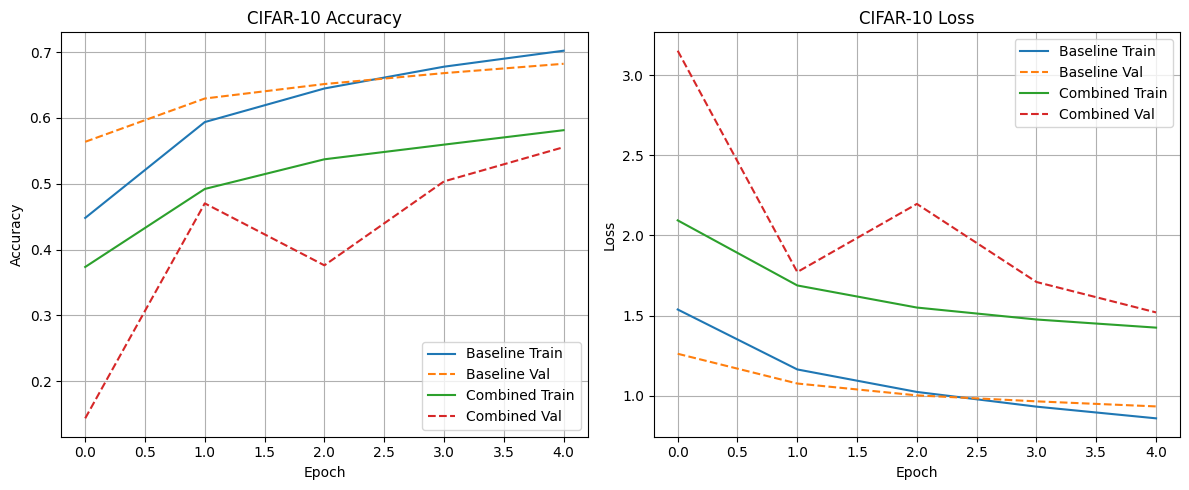

In [ ]:
plt.figure(figsize=(12, 5))

# ---- Accuracy ----
plt.subplot(1, 2, 1)
for cfg_name in ['Baseline', 'Combined']:
    hist = histories['cifar10'][cfg_name]
    plt.plot(hist.history['accuracy'],     label=f'{cfg_name} Train')
    plt.plot(hist.history['val_accuracy'], label=f'{cfg_name} Val', linestyle='--')
plt.title('CIFAR-10 Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True)

# ---- Loss ----
plt.subplot(1, 2, 2)
for cfg_name in ['Baseline', 'Combined']:
    hist = histories['cifar10'][cfg_name]
    plt.plot(hist.history['loss'],     label=f'{cfg_name} Train')
    plt.plot(hist.history['val_loss'], label=f'{cfg_name} Val', linestyle='--')
plt.title('CIFAR-10 Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves_cifar10.png', dpi=120)
plt.show()

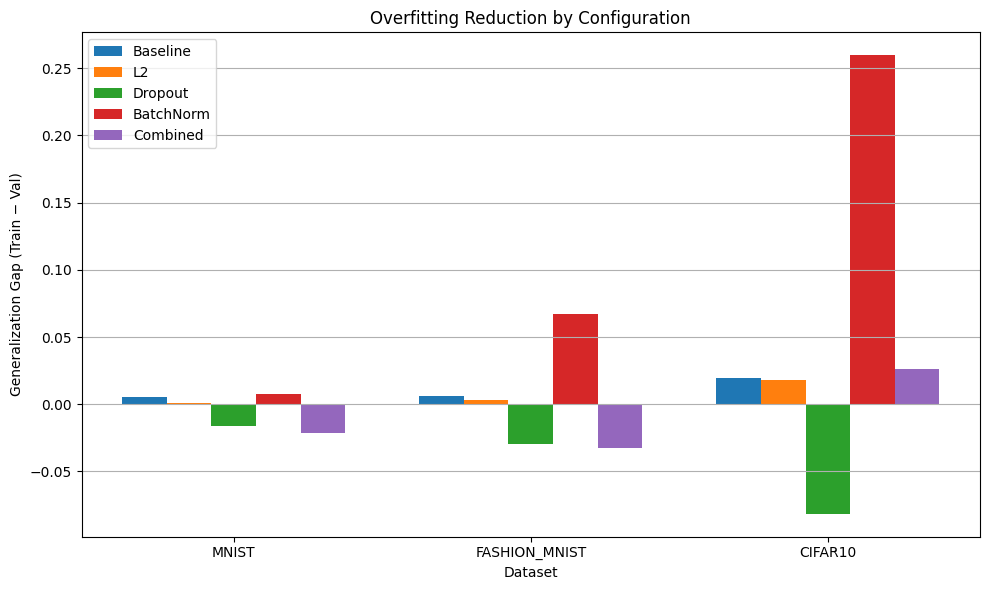

In [ ]:
gaps = {ds: {} for ds in DATASETS}
for ds in DATASETS:
    for cfg_name in CONFIGS.keys():
        h = histories[ds][cfg_name]
        gaps[ds][cfg_name] = h.history['accuracy'][-1] - h.history['val_accuracy'][-1]

plt.figure(figsize=(10, 6))
x = np.arange(len(DATASETS))
width = 0.15
for i, cfg_name in enumerate(CONFIGS.keys()):
    vals = [gaps[ds][cfg_name] for ds in DATASETS]
    plt.bar(x + i * width, vals, width, label=cfg_name)
plt.xlabel('Dataset')
plt.ylabel('Generalization Gap (Train − Val)')
plt.title('Overfitting Reduction by Configuration')
plt.xticks(x + width * 2, [ds.upper() for ds in DATASETS])
plt.legend(); plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig('generalization_gap.png', dpi=120)
plt.show()

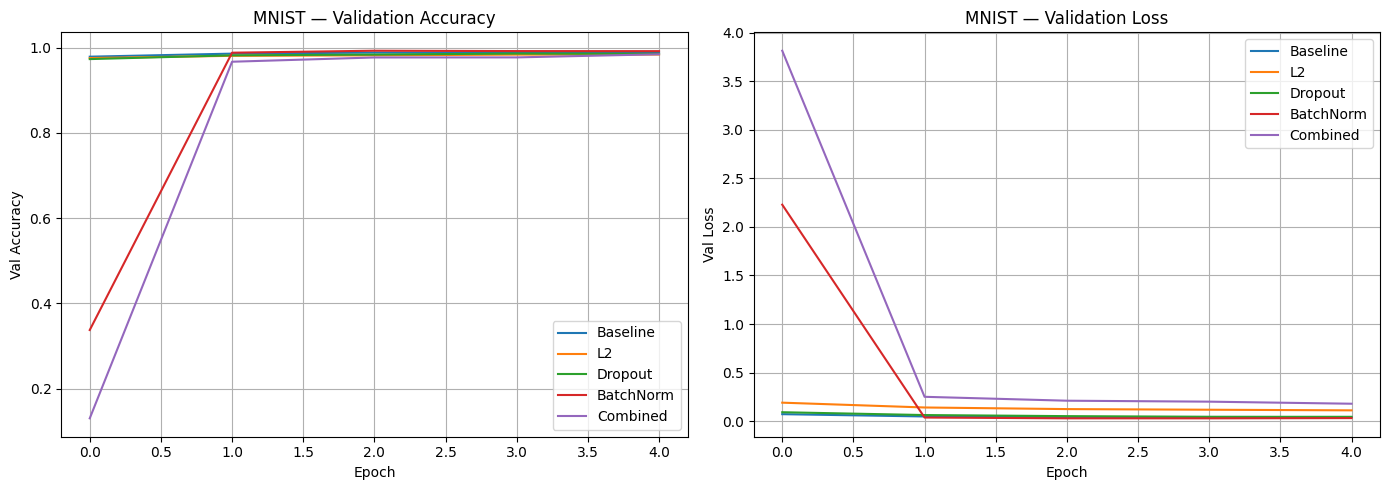

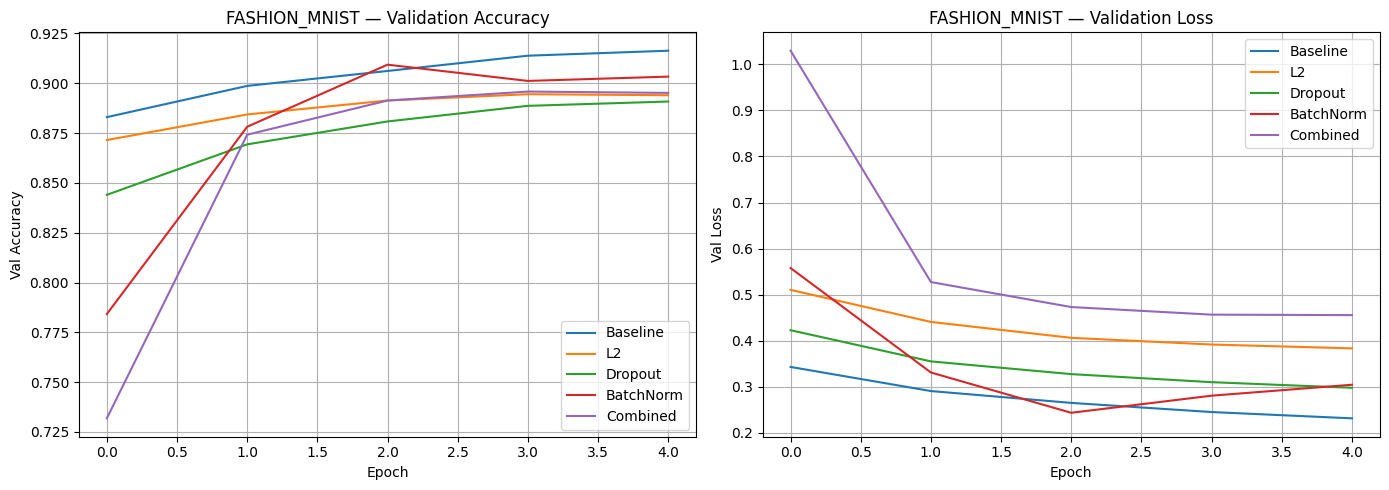

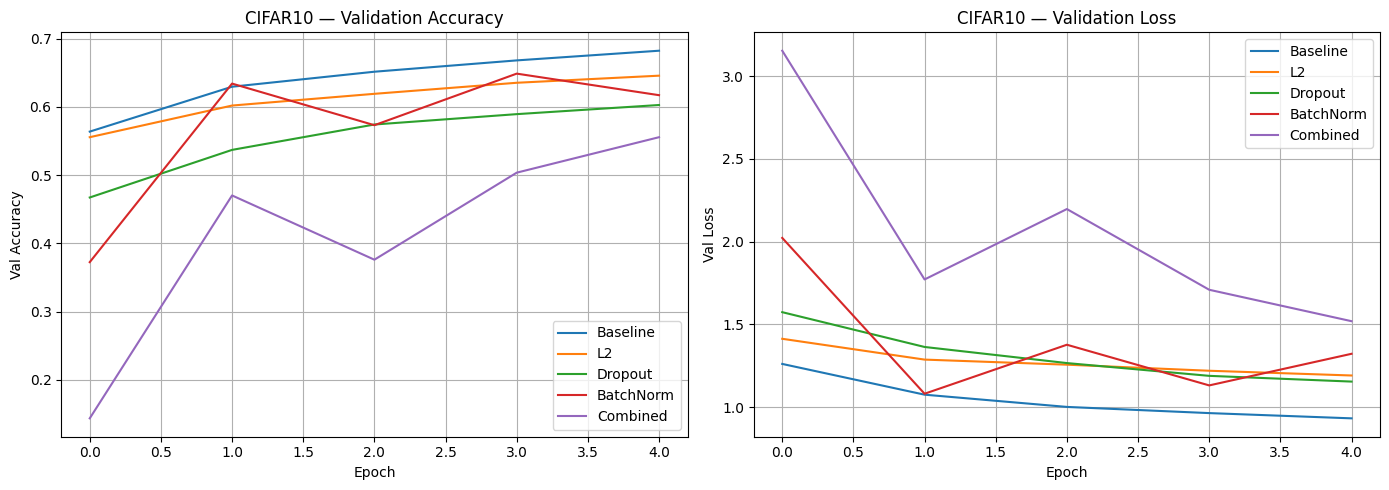

In [ ]:
for ds in DATASETS:
    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    for cfg_name in CONFIGS.keys():
        hist = histories[ds][cfg_name]
        plt.plot(hist.history['val_accuracy'], label=cfg_name)
    plt.title(f'{ds.upper()} — Validation Accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Val Accuracy')
    plt.legend(); plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    for cfg_name in CONFIGS.keys():
        hist = histories[ds][cfg_name]
        plt.plot(hist.history['val_loss'], label=cfg_name)
    plt.title(f'{ds.upper()} — Validation Loss')
    plt.xlabel('Epoch'); plt.ylabel('Val Loss')
    plt.legend(); plt.grid(True)

    plt.tight_layout()
    plt.savefig(f'curves_{ds}.png', dpi=120)
    plt.show()

In [ ]:
print("=" * 70)
print("           REGULARIZATION ANALYSIS SUMMARY")
print("=" * 70)

for ds in DATASETS:
    print(f"\n📊 Dataset: {ds.upper()}")
    best = max(results[ds], key=results[ds].get)
    base = results[ds]['Baseline']
    print(f"   Baseline Acc       : {base:.4f}")
    print(f"   Best Config        : {best} ({results[ds][best]:.4f})")
    print(f"   Improvement        : +{(results[ds][best] - base) * 100:.2f}%")
    print(f"   Baseline Gap       : {gaps[ds]['Baseline']:.4f}")
    print(f"   Best Gap           : {gaps[ds][best]:.4f}")
    print(f"   Gap Reduction      : {(gaps[ds]['Baseline'] - gaps[ds][best]) / gaps[ds]['Baseline'] * 100:.1f}%")

print("\n✅ Done.")

           REGULARIZATION ANALYSIS SUMMARY

📊 Dataset: MNIST
   Baseline Acc       : 0.9880
   Best Config        : BatchNorm (0.9908)
   Improvement        : +0.28%
   Baseline Gap       : 0.0050
   Best Gap           : 0.0073
   Gap Reduction      : -45.8%

📊 Dataset: FASHION_MNIST
   Baseline Acc       : 0.9081
   Best Config        : Baseline (0.9081)
   Improvement        : +0.00%
   Baseline Gap       : 0.0062
   Best Gap           : 0.0062
   Gap Reduction      : 0.0%

📊 Dataset: CIFAR10
   Baseline Acc       : 0.6690
   Best Config        : Baseline (0.6690)
   Improvement        : +0.00%
   Baseline Gap       : 0.0199
   Best Gap           : 0.0199
   Gap Reduction      : 0.0%

✅ Done.


🚀 Running L1 Regularization Experiments...

===== Dataset: MNIST =====
  L1 Test Accuracy: 0.9673 | Time: 24.4s
===== Dataset: FASHION_MNIST =====
  L1 Test Accuracy: 0.8541 | Time: 23.9s
===== Dataset: CIFAR10 =====
  L1 Test Accuracy: 0.4820 | Time: 28.2s

===== L1 REGULARIZATION RESULTS =====
MNIST           | Test Accuracy: 0.9673
FASHION_MNIST   | Test Accuracy: 0.8541
CIFAR10         | Test Accuracy: 0.4820


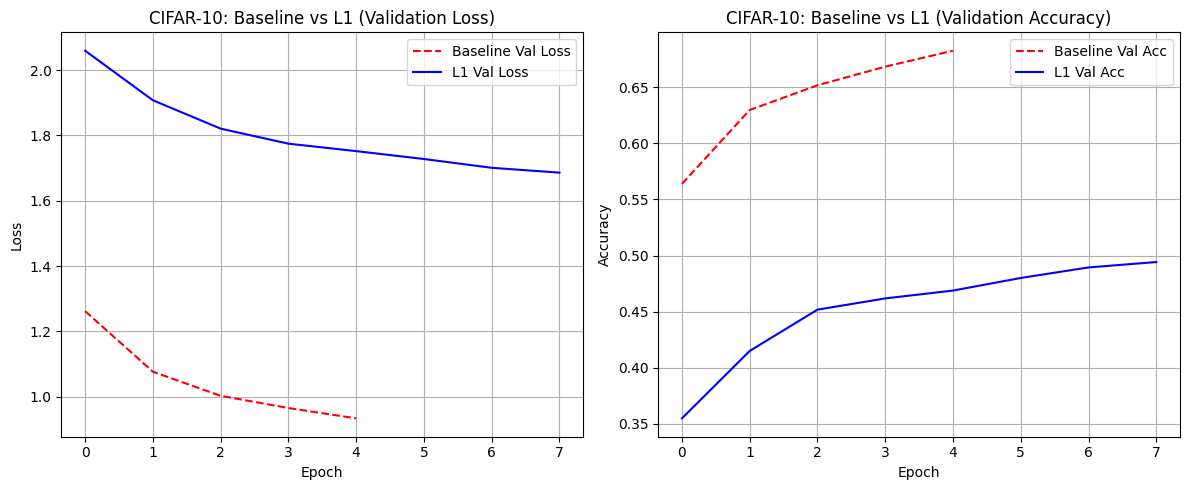


✅ L1 Regularization experiment complete!


In [ ]:
import gc
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Define ONLY the L1 Configuration
L1_CONFIG = {
    'l1': 0.001,   # L1 regularization strength
    'l2': 0.0,     # No L2
    'dropout': 0.0,
    'use_bn': False
}

# 2. Setup variables
DATASETS = ['mnist', 'fashion_mnist', 'cifar10']
EPOCHS = 8
l1_results = {}
l1_histories = {}

# 3. Run the L1 Experiment across all 3 datasets
print("🚀 Running L1 Regularization Experiments...\n")
for ds in DATASETS:
    print(f"===== Dataset: {ds.upper()} =====")
    acc, hist, t = train_and_evaluate(ds, L1_CONFIG, epochs=EPOCHS, verbose=0)
    l1_results[ds] = acc
    l1_histories[ds] = hist
    print(f"  L1 Test Accuracy: {acc:.4f} | Time: {t:.1f}s")

    # Clear memory to prevent Colab crash
    tf.keras.backend.clear_session()
    gc.collect()

# 4. Print Results Table
print("\n===== L1 REGULARIZATION RESULTS =====")
for ds in DATASETS:
    print(f"{ds.upper():<15} | Test Accuracy: {l1_results[ds]:.4f}")

# 5. Plot L1 vs Baseline on CIFAR-10 (where overfitting is worst)
plt.figure(figsize=(12, 5))

# Check if baseline histories exist from your previous run
if 'histories' in globals() and 'cifar10' in histories and 'Baseline' in histories['cifar10']:
    plt.subplot(1, 2, 1)
    plt.plot(histories['cifar10']['Baseline'].history['val_loss'], label='Baseline Val Loss', color='red', linestyle='--')
    plt.plot(l1_histories['cifar10'].history['val_loss'], label='L1 Val Loss', color='blue')
    plt.title('CIFAR-10: Baseline vs L1 (Validation Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(histories['cifar10']['Baseline'].history['val_accuracy'], label='Baseline Val Acc', color='red', linestyle='--')
    plt.plot(l1_histories['cifar10'].history['val_accuracy'], label='L1 Val Acc', color='blue')
    plt.title('CIFAR-10: Baseline vs L1 (Validation Accuracy)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
else:
    # If baseline wasn't found, just plot L1
    plt.subplot(1, 2, 1)
    plt.plot(l1_histories['cifar10'].history['val_loss'], label='L1 Val Loss', color='blue')
    plt.title('CIFAR-10: L1 Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

print("\n✅ L1 Regularization experiment complete!")

Add Bias & Variance Analysis code

In [ ]:
# Bias-Variance Analysis

print("BIAS-VARIANCE ANALYSIS")
print("=" * 50)

print("\nHigh Bias (Underfitting):")
print("If training and validation accuracy are both low,")
print("the model may be underfitting the data.")

print("\nHigh Variance (Overfitting):")
print("If training accuracy is much higher than validation accuracy,")
print("the model may be overfitting the training data.")

print("\nRegularization:")
print("L1 and L2 regularization help reduce model complexity.")

print("\nDropout:")
print("Dropout reduces overfitting by randomly disabling neurons during training.")

print("\nBatch Normalization:")
print("Batch Normalization helps stabilize and improve neural network training.")

print("\nEarly Stopping:")
print("Early Stopping stops training when validation performance stops improving.")

BIAS-VARIANCE ANALYSIS

High Bias (Underfitting):
If training and validation accuracy are both low,
the model may be underfitting the data.

High Variance (Overfitting):
If training accuracy is much higher than validation accuracy,
the model may be overfitting the training data.

Regularization:
L1 and L2 regularization help reduce model complexity.

Dropout:
Dropout reduces overfitting by randomly disabling neurons during training.

Batch Normalization:
Batch Normalization helps stabilize and improve neural network training.

Early Stopping:
Early Stopping stops training when validation performance stops improving.


Create a Model Comparison Table

In [ ]:
# Model Comparison Table

import pandas as pd

comparison_data = {
    "Model": [
        "Baseline",
        "L1 Regularization",
        "L2 Regularization",
        "Dropout",
        "Batch Normalization",
        "Combined + Early Stopping"
    ],
    "Technique": [
        "No Regularization",
        "L1",
        "L2",
        "Dropout",
        "Batch Normalization",
        "L1/L2 + Dropout + BatchNorm + Early Stopping"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("MODEL COMPARISON")
print("=" * 80)

display(comparison_df)

MODEL COMPARISON


,Model,Technique
0,Baseline,No Regularization
1,L1 Regularization,L1
2,L2 Regularization,L2
3,Dropout,Dropout
4,Batch Normalization,Batch Normalization
5,Combined + Early Stopping,L1/L2 + Dropout + BatchNorm + Early Stopping


In [ ]:
# Find variables currently available in the notebook

print("Variables containing 'history':")

history_variables = [
    name for name in globals()
    if "history" in name.lower()
]

print(history_variables)

Variables containing 'history':
[]


In [ ]:
# Find model and training-related variables

keywords = ["model", "train", "accuracy", "loss"]

found_variables = []

for name in globals():
    if any(keyword in name.lower() for keyword in keywords):
        found_variables.append(name)

print("Model/training-related variables:")
print(found_variables)

Model/training-related variables:
['models', 'create_model', 'train_and_evaluate']


In [ ]:
# Check available variables related to models and results

for name, value in globals().items():
    if any(word in name.lower() for word in [
        "model", "history", "accuracy", "loss"
    ]):
        print(name, "->", type(value).__name__)

models -> module
create_model -> function
history_variables -> list


In [ ]:
# Display all Sequential/Keras models currently available

import tensorflow as tf

models_found = {}

for name, value in globals().items():
    if isinstance(value, tf.keras.Model):
        models_found[name] = value

print("Models found:")
for name in models_found:
    print("-", name)

Models found:


In [ ]:
# Evaluate all available models

results = []

for name, model in models_found.items():

    try:
        loss, accuracy = model.evaluate(
            x_test,
            y_test,
            verbose=0
        )

        results.append({
            "Model": name,
            "Test Loss": loss,
            "Test Accuracy": accuracy
        })

    except Exception as e:
        print(f"Could not evaluate {name}: {e}")

results_df = pd.DataFrame(results)

display(results_df)

""


In [ ]:
# Find variables related to test data

print("Variables containing test/x/y/data:")
print("=" * 50)

for name in globals():
    if any(word in name.lower() for word in [
        "x_test",
        "y_test",
        "test",
        "xtrain",
        "ytrain"
    ]):
        print(name)

Variables containing test/x/y/data:


In [ ]:
# Find training and validation variables

print("Training / Validation variables")
print("=" * 50)

for name in globals():
    if any(word in name.lower() for word in [
        "x_train",
        "y_train",
        "x_val",
        "y_val",
        "validation",
        "train"
    ]):
        print(name)

Training / Validation variables
train_and_evaluate
